# Notebook 03: Análisis Exploratorio de Datos (EDA)

## Objetivo
Explorar el dataset limpio de TAWOS para comprender la distribución de las variables objetivo,
identificar correlaciones entre features y justificar las decisiones de modelado.
Los gráficos generados sirven de soporte visual para la memoria del TFG (Sección 6.3.1).

In [85]:
# 1. IMPORTACIONES Y CONFIGURACIÓN VISUAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import PercentFormatter
warnings.filterwarnings('ignore') # Ocultar avisos de librerías para mantener el cuaderno limpio

# Configuración de estilo profesional para el TFG (Memoria)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12, 
    'figure.figsize': (10, 6),
    'axes.titlepad': 15,
    'axes.titleweight': 'bold'
})
colores_target = ['#2ECC71', '#E74C3C'] # Verde (A tiempo/Seguro) y Rojo (Retraso/Riesgo)

# Carga del Dataset Limpio
df = pd.read_csv('../data/processed/dataset_entrenamiento_tawos.csv')
print(f"✅ Dataset cargado correctamente: {df.shape[0]} tareas listas para análisis exploratorio.")
display(df.head(3))

✅ Dataset cargado correctamente: 142151 tareas listas para análisis exploratorio.


,Issue_Key,Issue_Type,Project_ID,Project_Name,Sprint_ID,Sprint_State,Story_Point,Total_Effort_Minutes,In_Progress_Minutes,Resolution_Time_Minutes,Title_Changed_After_Estimation,Description_Changed_After_Estimation,Story_Point_Changed_After_Estimation,Blocker_Count,Target_Retraso,Target_Riesgo
0,XD-3748,Bug,1,Spring XD,-1,UNASSIGNED,1.0,428822.0,87.0,436558.0,0,0,0,0,0,1
1,XD-3747,Enhancement,1,Spring XD,-1,UNASSIGNED,1.0,336752.0,2.0,437537.0,1,0,0,0,0,1
2,XD-3744,Enhancement,1,Spring XD,1,CLOSED,1.0,172.0,13.0,194.0,0,0,0,0,0,0


## 1. Distribución de las variables objetivo
Analizamos el balance de clases para `Target_Retraso` y `Target_Riesgo`.
Un desbalanceo significativo condicionará la estrategia de ponderación de clases durante el entrenamiento.

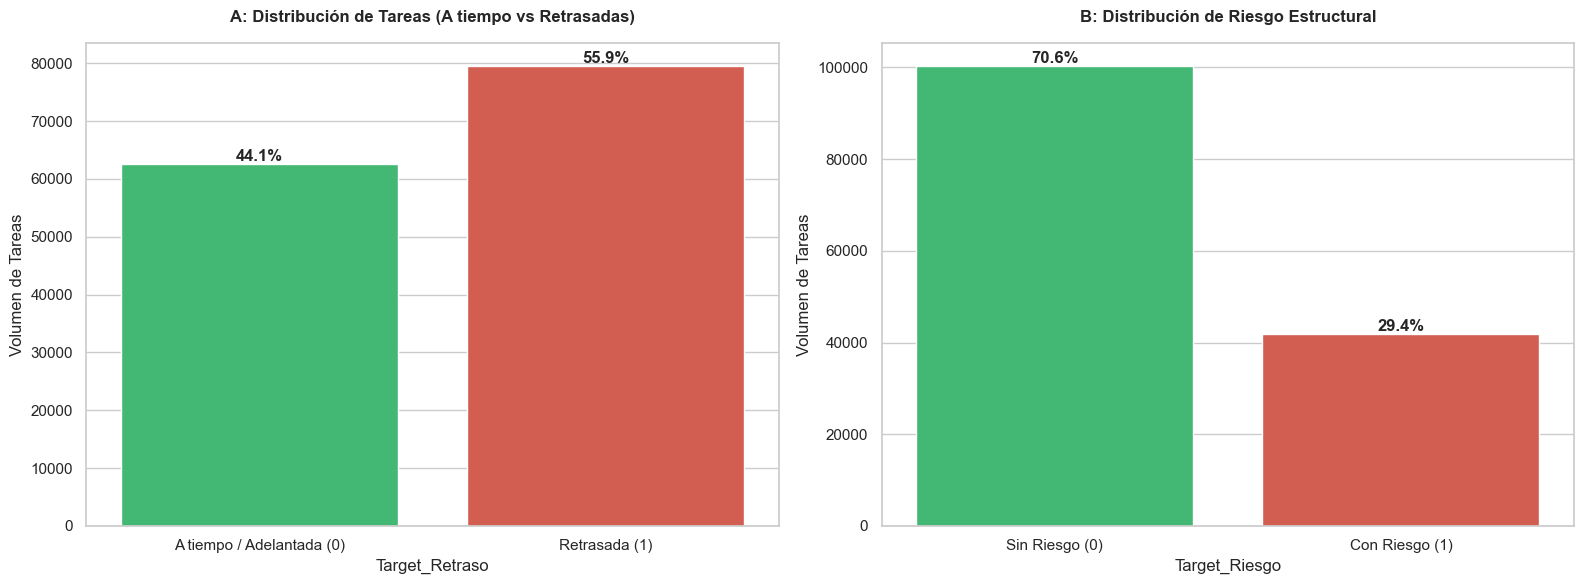

In [86]:
# 2. ANÁLISIS DE DISTRIBUCIÓN DE CLASES (EL PROBLEMA EMPÍRICO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Retrasos
ax1 = sns.countplot(data=df, x='Target_Retraso', hue='Target_Retraso', palette=colores_target, legend=False, ax=axes[0])
axes[0].set_title('A: Distribución de Tareas (A tiempo vs Retrasadas)')
axes[0].set_xticklabels(['A tiempo / Adelantada (0)', 'Retrasada (1)'])
axes[0].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico A
total1 = len(df)
for p in ax1.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax1.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), #coloca el texto de la barra
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# Gráfico B: Riesgos
ax2 = sns.countplot(data=df, x='Target_Riesgo', hue='Target_Riesgo', palette=colores_target, legend=False, ax=axes[1])
axes[1].set_title('B: Distribución de Riesgo Estructural')
axes[1].set_xticklabels(['Sin Riesgo (0)', 'Con Riesgo (1)'])
axes[1].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico B
for p in ax2.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax2.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
# Descomenta la siguiente línea si quieres que la imagen se guarde sola en tu disco duro
plt.savefig('../data/figures/distribucion_targets.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Matriz de correlación
Mapa de calor con los coeficientes de Pearson entre las variables numéricas principales.
Permite detectar colinearidades entre variables predictoras y evaluar qué *features*
tienen mayor relación lineal con los *targets*.

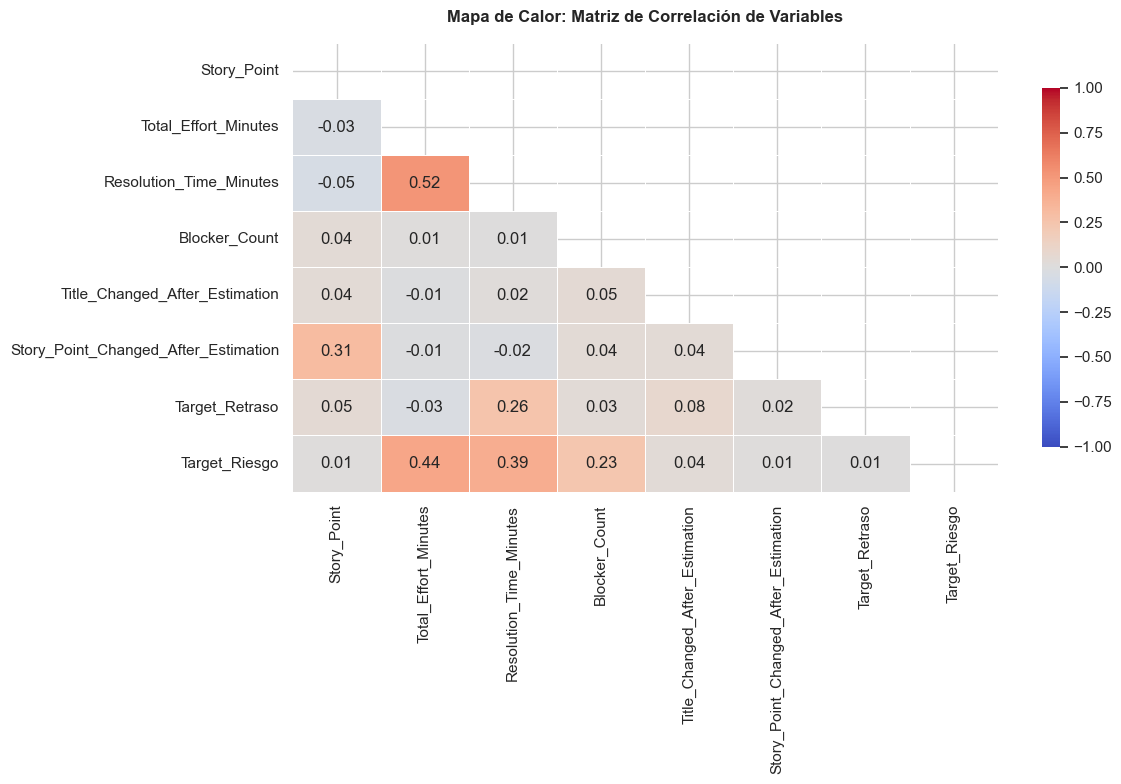

In [87]:
# 3. MATRIZ DE CORRELACIÓN (¿Qué influye en los retrasos y riesgos?)
cols_correlacion = [
    'Story_Point', 'Total_Effort_Minutes', 'Resolution_Time_Minutes', 
    'Blocker_Count', 'Title_Changed_After_Estimation', 
    'Story_Point_Changed_After_Estimation', 
    'Target_Retraso', 'Target_Riesgo'
]

plt.figure(figsize=(12, 8))
matriz_corr = df[cols_correlacion].corr() #coeficiente correlación pearson

# Crear máscara para ocultar el triángulo superior (hace que el gráfico sea más elegante y limpio)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f",  
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8}) #creación mapa de calor

plt.title('Mapa de Calor: Matriz de Correlación de Variables')
plt.tight_layout()
plt.savefig('../data/figures/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Impacto de los bloqueos en retraso y riesgo
Analizamos cómo la cantidad de bloqueos activos (`Blocker_Count`) afecta a la probabilidad de retraso (`Target_Retraso`) y de riesgo (`Target_Riesgo`).
En el retraso, los bloqueos actúan como variable predictora independiente. En el riesgo, forman parte de la definición de la variable objetivo.
Este análisis permite validar la relevancia de `Blocker_Count` como *feature* en el modelo de retrasos y evidenciar su relación con `Target_Riesgo`, lo que motiva su exclusión del modelo de riesgos para evitar *data leakage*.

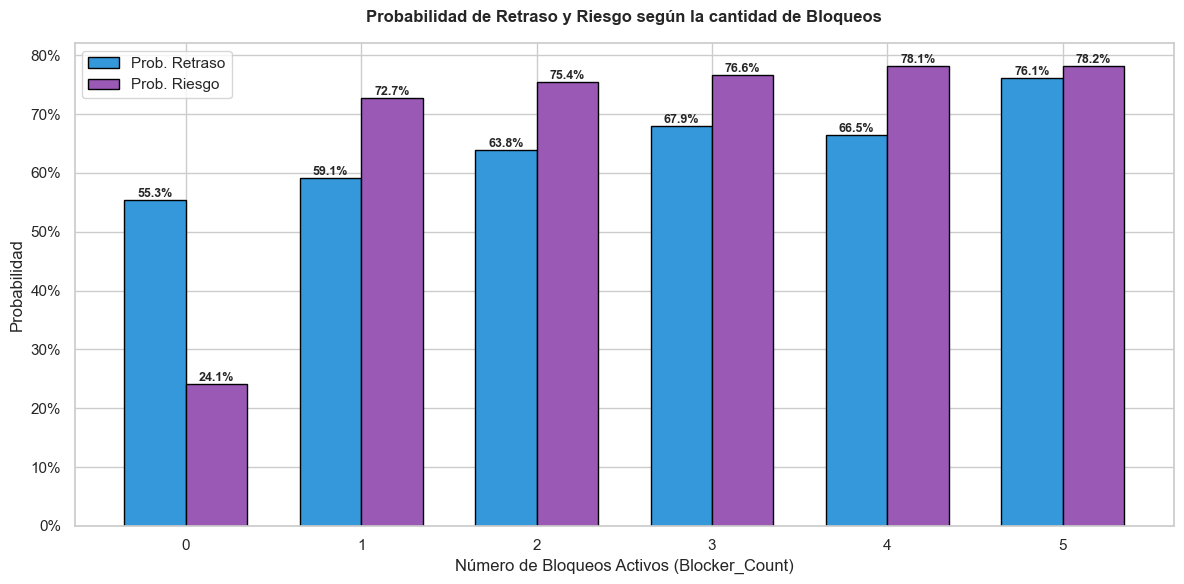

In [88]:
# 4. IMPACTO DE LOS BLOQUEOS EN RETRASO Y RIESGO
df_bloqueos = df[df['Blocker_Count'] <= 5]
bloqueo_stats = df_bloqueos.groupby('Blocker_Count').agg(
    P_Retraso=('Target_Retraso', 'mean'),
    P_Riesgo=('Target_Riesgo', 'mean'),
    Count=('Target_Retraso', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bloqueo_stats))
width = 0.35

bars1 = ax.bar(x - width/2, bloqueo_stats['P_Retraso'], width, label='Prob. Retraso', color='#3498DB', edgecolor='black')
bars2 = ax.bar(x + width/2, bloqueo_stats['P_Riesgo'], width, label='Prob. Riesgo', color='#9B59B6', edgecolor='black')

ax.set_xlabel('Número de Bloqueos Activos (Blocker_Count)')
ax.set_ylabel('Probabilidad')
ax.set_title('Probabilidad de Retraso y Riesgo según la cantidad de Bloqueos')
ax.set_xticks(x)
ax.set_xticklabels(bloqueo_stats['Blocker_Count'].astype(int))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

for bar in bars1:
    ax.annotate(f"{bar.get_height()*100:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.annotate(f"{bar.get_height()*100:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../data/figures/impacto_bloqueos.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Tasa de retraso y riesgo por tipo de tarea
Calculamos qué porcentaje de tareas de cada tipo acaban retrasadas y en riesgo.
Esto permite justificar la inclusión de `Issue_Type` como variable categórica en ambos modelos
y entender qué categorías son más propensas a desviaciones del cronograma.

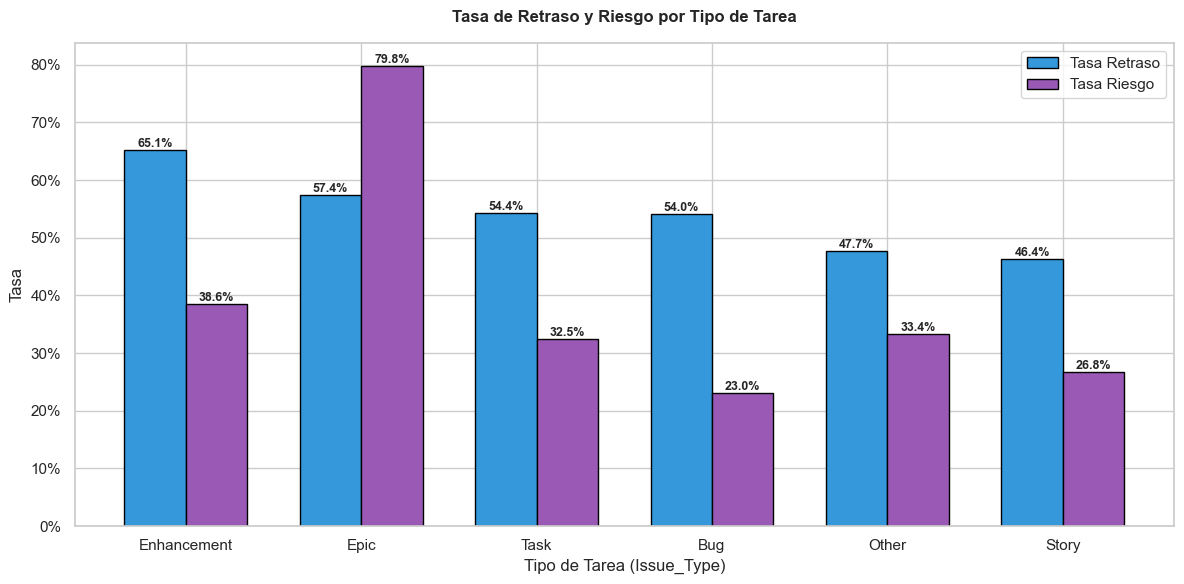

In [89]:
tipo_stats = df.groupby('Issue_Type').agg(
    Tasa_Retraso=('Target_Retraso', 'mean'),
    Tasa_Riesgo=('Target_Riesgo', 'mean'),
    Count=('Target_Retraso', 'count')
).sort_values('Tasa_Retraso', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tipo_stats))
width = 0.35

bars1 = ax.bar(x - width/2, tipo_stats['Tasa_Retraso'], width, label='Tasa Retraso', color='#3498DB', edgecolor='black')
bars2 = ax.bar(x + width/2, tipo_stats['Tasa_Riesgo'], width, label='Tasa Riesgo', color='#9B59B6', edgecolor='black')

ax.set_xlabel('Tipo de Tarea (Issue_Type)')
ax.set_ylabel('Tasa')
ax.set_title('Tasa de Retraso y Riesgo por Tipo de Tarea')
ax.set_xticks(x)
ax.set_xticklabels(tipo_stats['Issue_Type'])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

for bar in bars1:
    ax.annotate(f"{bar.get_height()*100:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.annotate(f"{bar.get_height()*100:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../data/figures/tasa_retraso_riesgo_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Distribución de variables de estimación
Inspeccionamos las distribuciones de `Story_Point` y `Total_Effort_Minutes`.
El 50\% de las tareas no tienen Story Points asignados, y el esfuerzo total oscila entre 1 y 2.571.350 minutos.
Esta disparidad en los rangos de las variables numéricas justifica la aplicación de `StandardScaler`
en los *pipelines* de preprocesado para evitar que las variables de mayor magnitud dominen el modelo.

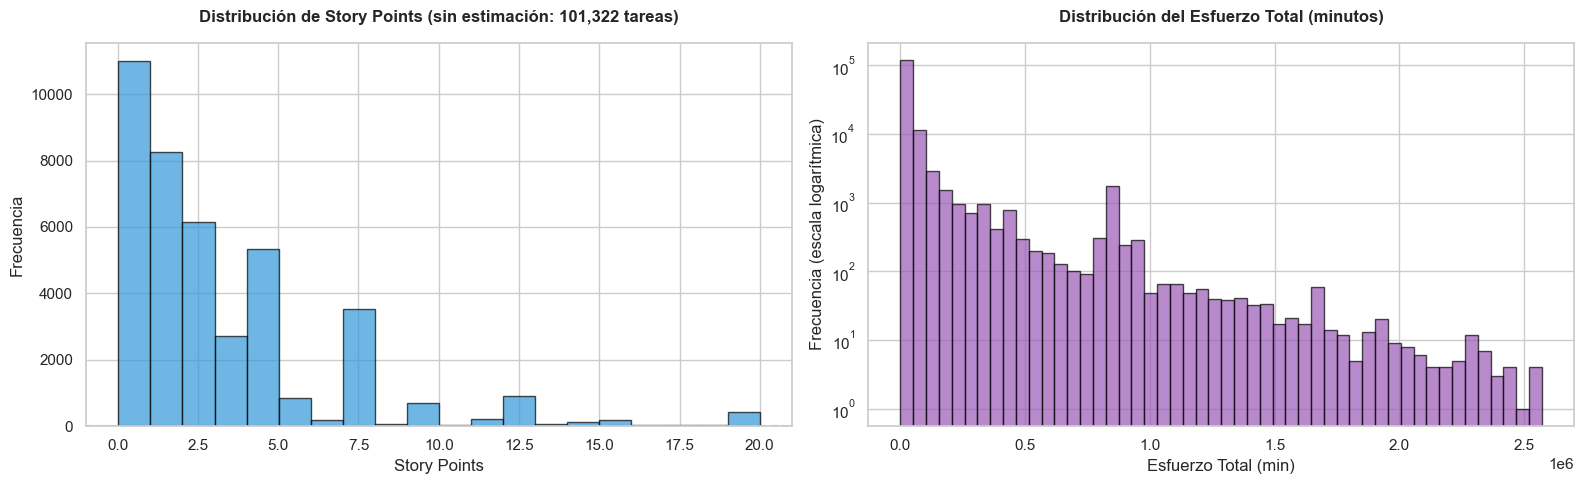

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Story Points
sp_nonzero = df['Story_Point'][df['Story_Point'] > 0]
sp_zero = (df['Story_Point'] == 0).sum()
axes[0].hist(sp_nonzero, bins=20, color='#3498DB', edgecolor='black', alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(f'Distribución de Story Points (sin estimación: {sp_zero:,} tareas)')
axes[0].set_xlabel('Story Points')
axes[0].set_ylabel('Frecuencia')

# Total_Effort_Minutes (escala logarítmica en X)
effort = df['Total_Effort_Minutes'][df['Total_Effort_Minutes'] > 0]
axes[1].hist(effort, bins=50, color='#9B59B6', edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Distribución del Esfuerzo Total (minutos)')
axes[1].set_xlabel('Esfuerzo Total (min)')
axes[1].set_ylabel('Frecuencia (escala logarítmica)')

plt.tight_layout()
plt.savefig('../data/figures/distribucion_esfuerzo.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Impacto del cambio de título tras la estimación
Analizamos si las tareas cuyo título fue modificado después de la estimación (`Title_Changed_After_Estimation`)
presentan mayor probabilidad de retraso y riesgo. Esto valida su inclusión como variable de auditoría en los modelos.

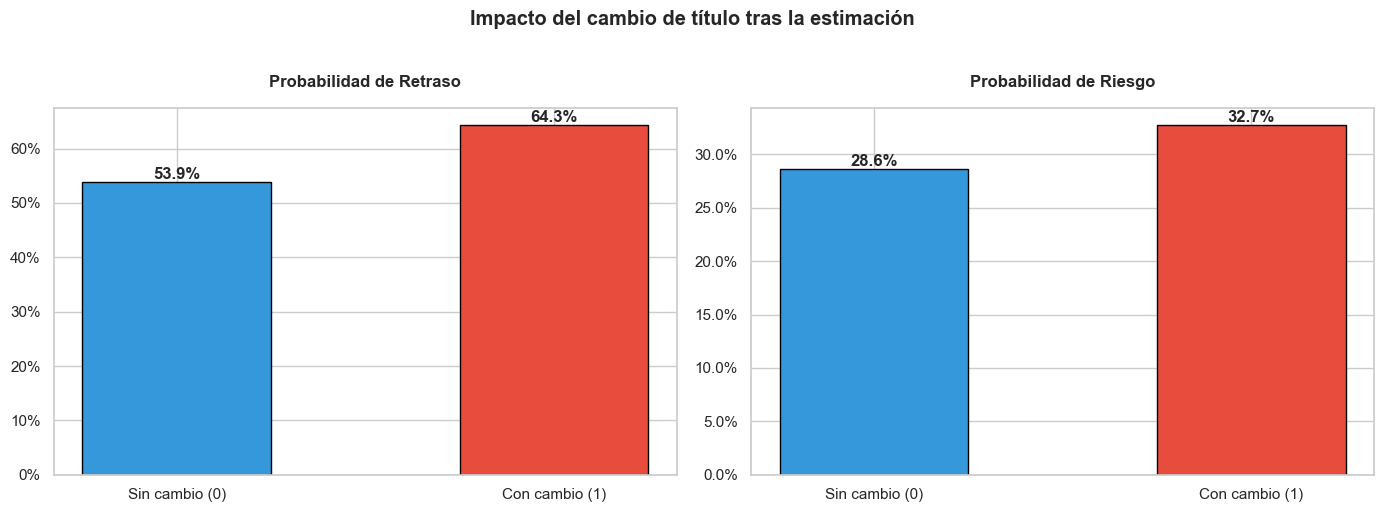

In [91]:
cambio_stats = df.groupby('Title_Changed_After_Estimation').agg(
    P_Retraso=('Target_Retraso', 'mean'),
    P_Riesgo=('Target_Riesgo', 'mean'),
    Count=('Target_Retraso', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Sin cambio (0)', 'Con cambio (1)']
x = np.arange(len(labels))
width = 0.5

axes[0].bar(x, cambio_stats['P_Retraso'], width, color=['#3498DB', '#E74C3C'], edgecolor='black')
axes[0].set_title('Probabilidad de Retraso')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
for i, v in enumerate(cambio_stats['P_Retraso']):
    axes[0].annotate(f"{v*100:.1f}%", (i, v), ha='center', va='bottom', fontweight='bold')

axes[1].bar(x, cambio_stats['P_Riesgo'], width, color=['#3498DB', '#E74C3C'], edgecolor='black')
axes[1].set_title('Probabilidad de Riesgo')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for i, v in enumerate(cambio_stats['P_Riesgo']):
    axes[1].annotate(f"{v*100:.1f}%", (i, v), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Impacto del cambio de título tras la estimación', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/impacto_title_changed.png', dpi=300, bbox_inches='tight')
plt.show()